In [318]:
#EDA
import pandas as pd
import numpy as np
import plotly.express as px
from plotly._subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from mlxtend.frequent_patterns import apriori, association_rules

### Carregar Dados

In [319]:
df = pd.read_csv('./datasets/transations_by_dept.csv', sep=',')

In [320]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4539 entries, 0 to 4538
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   POS Txn  4539 non-null   uint64
 1   Dept     4539 non-null   str   
 2   ID       4539 non-null   int64 
 3   Sales U  4539 non-null   int64 
dtypes: int64(2), str(1), uint64(1)
memory usage: 142.0 KB


In [321]:
df.head(10)

,POS Txn,Dept,ID,Sales U
0,16120100160021008773,0261:HOSIERY,250,2
1,16120100160021008773,0634:VITAMINS & HLTH AIDS,102,1
2,16120100160021008773,0879:PET SUPPLIES,158,2
3,16120100160021008773,0973:CANDY,175,2
4,16120100160021008773,0982:SPIRITS,176,1
5,16120100160021008773,0983:WINE,177,4
6,16120100160021008773,0991:TOBACCO,179,2
7,16120100160021008774,0597:HEALTH AIDS,93,1
8,16120100160021008774,0604:PERSONAL CARE,100,5
9,16120100160021008775,0819:PRE-RECORDED A/V,135,1


In [322]:
df.tail(10)

,POS Txn,Dept,ID,Sales U
4529,16120100160162000841,0857:PC PERIPH/OFFICE ACC,155,1
4530,16120100160162000841,0931:BATH,165,1
4531,16120100160162000841,0941:BEDDING,167,1
4532,16120100160162000841,0991:TOBACCO,179,1
4533,16120100160162000842,0815:AUDIO ELECTRONICS,132,1
4534,16120100160162000843,0857:PC PERIPH/OFFICE ACC,155,1
4535,16120100160162000845,0395:MENS ATHLETIC SHOES,49,1
4536,16120100160162000845,0815:AUDIO ELECTRONICS,132,1
4537,16120100160162000846,0532:AMERICAN GREETINGS,72,1
4538,16120100160221001467,0066:VENDING/AMUSEMENT MA,242,1


### EDA

In [323]:
df.rename(columns={'POS Txn': 'ID_Transacao', 'Dept': 'Departamento', 'ID': 'ID_Departamento', 'Sales U': 'Qtd_Vendida'}, inplace=True)

In [324]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4539 entries, 0 to 4538
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID_Transacao     4539 non-null   uint64
 1   Departamento     4539 non-null   str   
 2   ID_Departamento  4539 non-null   int64 
 3   Qtd_Vendida      4539 non-null   int64 
dtypes: int64(2), str(1), uint64(1)
memory usage: 142.0 KB


In [325]:
df['Departamento'].nunique()

160

In [326]:
df['ID_Departamento'].nunique()

160

In [327]:
df['ID_Transacao'].nunique()

2064

In [328]:
len(df.groupby(['ID_Transacao', 'Departamento'])) != len(df)

False

In [329]:
len(df[df['Qtd_Vendida'] <= 0])

149

In [330]:
df = df[df['Qtd_Vendida'] > 0]

In [331]:
contagem_transacoes_por_departamento = df.value_counts('Departamento')

fig_volume_transacoes = px.bar(contagem_transacoes_por_departamento, color=contagem_transacoes_por_departamento.index, orientation='h')
fig_volume_transacoes.update_layout(showlegend=False)
fig_volume_transacoes.show()

In [332]:
contagem_transacoes_por_departamento_top10 = df.value_counts('Departamento').head(10)

fig_volume_transacoes_top10 = px.bar(contagem_transacoes_por_departamento_top10, color=contagem_transacoes_por_departamento_top10.index, orientation='h')
fig_volume_transacoes_top10.update_layout(showlegend=False)
fig_volume_transacoes_top10.show()

In [333]:
soma_quantidade_por_departamento = df.groupby('Departamento')['Qtd_Vendida'].sum().sort_values(ascending=False)

fig_unidades_vendidas = px.bar(soma_quantidade_por_departamento, color=soma_quantidade_por_departamento.index, orientation='h')
fig_unidades_vendidas.update_layout(showlegend=False)
fig_unidades_vendidas.show()

In [334]:
soma_quantidade_por_departamento_top10 = df.groupby('Departamento')['Qtd_Vendida'].sum().sort_values(ascending=False).head(10)

fig_unidades_vendidas_top10 = px.bar(soma_quantidade_por_departamento_top10, color=soma_quantidade_por_departamento_top10.index, orientation='h')
fig_unidades_vendidas_top10.update_layout(showlegend=False)
fig_unidades_vendidas_top10.show()

In [335]:
fig_1 = make_subplots(rows=1, cols=2, subplot_titles=('Volume de Transações', 'Unidades Vendidas'))

for trace in fig_volume_transacoes_top10['data']:
    fig_1.add_trace(trace, row=1, col=1)

for trace in fig_unidades_vendidas_top10['data']:
    fig_1.add_trace(trace, row=1, col=2)

fig_1.update_layout(height=800, width=1250, title_text='Top10 Departamentos', showlegend=False)
fig_1.show()

In [336]:
desvio_padrao_quantidade_por_departamento_top20 = df.groupby('Departamento')['Qtd_Vendida'].std().sort_values(ascending=False).head(20)

fig_variacao_unidades_vendidas_top20 = px.bar(desvio_padrao_quantidade_por_departamento_top20, color=desvio_padrao_quantidade_por_departamento_top20.index, orientation='h')
fig_variacao_unidades_vendidas_top20.update_layout(showlegend=False)
fig_variacao_unidades_vendidas_top20.show()

In [337]:
px.box(df, x='Departamento', y='Qtd_Vendida')

In [338]:
media_quantidade_por_departamento_top20 = df.groupby('Departamento')['Qtd_Vendida'].mean().sort_values(ascending=False).head(20)

fig_media_unidades_vendidas_top20 = px.bar(media_quantidade_por_departamento_top20, color=media_quantidade_por_departamento_top20.index, orientation='h')
fig_media_unidades_vendidas_top20.update_layout(showlegend=False)
fig_media_unidades_vendidas_top20.show()

In [339]:
desvio_padrao_quantidade_por_departamento_top20 = df.groupby('Departamento')['Qtd_Vendida'].std().sort_values(ascending=False).head(20)

fig_1 = make_subplots(rows=1, cols=2, subplot_titles=('Desvio Padrão', 'Média'))

for trace in fig_variacao_unidades_vendidas_top20['data']:
    fig_1.add_trace(trace, row=1, col=1)

for trace in fig_media_unidades_vendidas_top20['data']:
    fig_1.add_trace(trace, row=1, col=2)

fig_1.update_layout(height=800, width=1250, title_text='Top20 Departamentos - Unidades Vendidas', showlegend=False)
fig_1.show()

### Preparação da Base com Pivot Table

In [340]:
df_pivot = df.pivot_table(
    index='ID_Transacao',
    columns='Departamento',
    values='Qtd_Vendida',
    aggfunc='sum'
)

In [341]:
df_pivot.head(20)

Departamento,0002:BARBER RETAIL,0009:FLORAL SERV/SUPPLIES,0012:LOCAL GIFTS/FOODS,0014:REPAIRS,0016:FINANCIAL SERVICES,0018:OTHER DIRECT SERVICE,0033:VENDING RETAIL,0056:SOUVENIR,0066:VENDING/AMUSEMENT MA,0071:BEAUTY RETAIL,...,0941:BEDDING,0961:GENERAL GROCERIES,0962:BEVERAGES,0965:PERISHABLES,0973:CANDY,0982:SPIRITS,0983:WINE,0984:BEER,0991:TOBACCO,0999:UNSCANNED ITEMS
ID_Transacao,,,,,,,,,,,,,,,,,,,,,
16120100160021008773,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,1.0,4.0,NaN,2.0,NaN
16120100160021008774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16120100160021008775,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
16120100160021008776,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16120100160021008777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
16120100160021008778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,1.0,NaN
16120100160021008779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0,NaN,NaN
16120100160021008780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16120100160021008781,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,1.0,NaN,2.0,NaN,NaN,NaN


In [342]:
df_pivot = df_pivot.map(lambda x: True if x > 0 else False)

In [343]:
df_pivot = df_pivot.rename_axis(None, axis=1)

In [344]:
df_pivot.reset_index(inplace=True)

In [345]:
df_pivot.drop('ID_Transacao', axis=1, inplace=True)

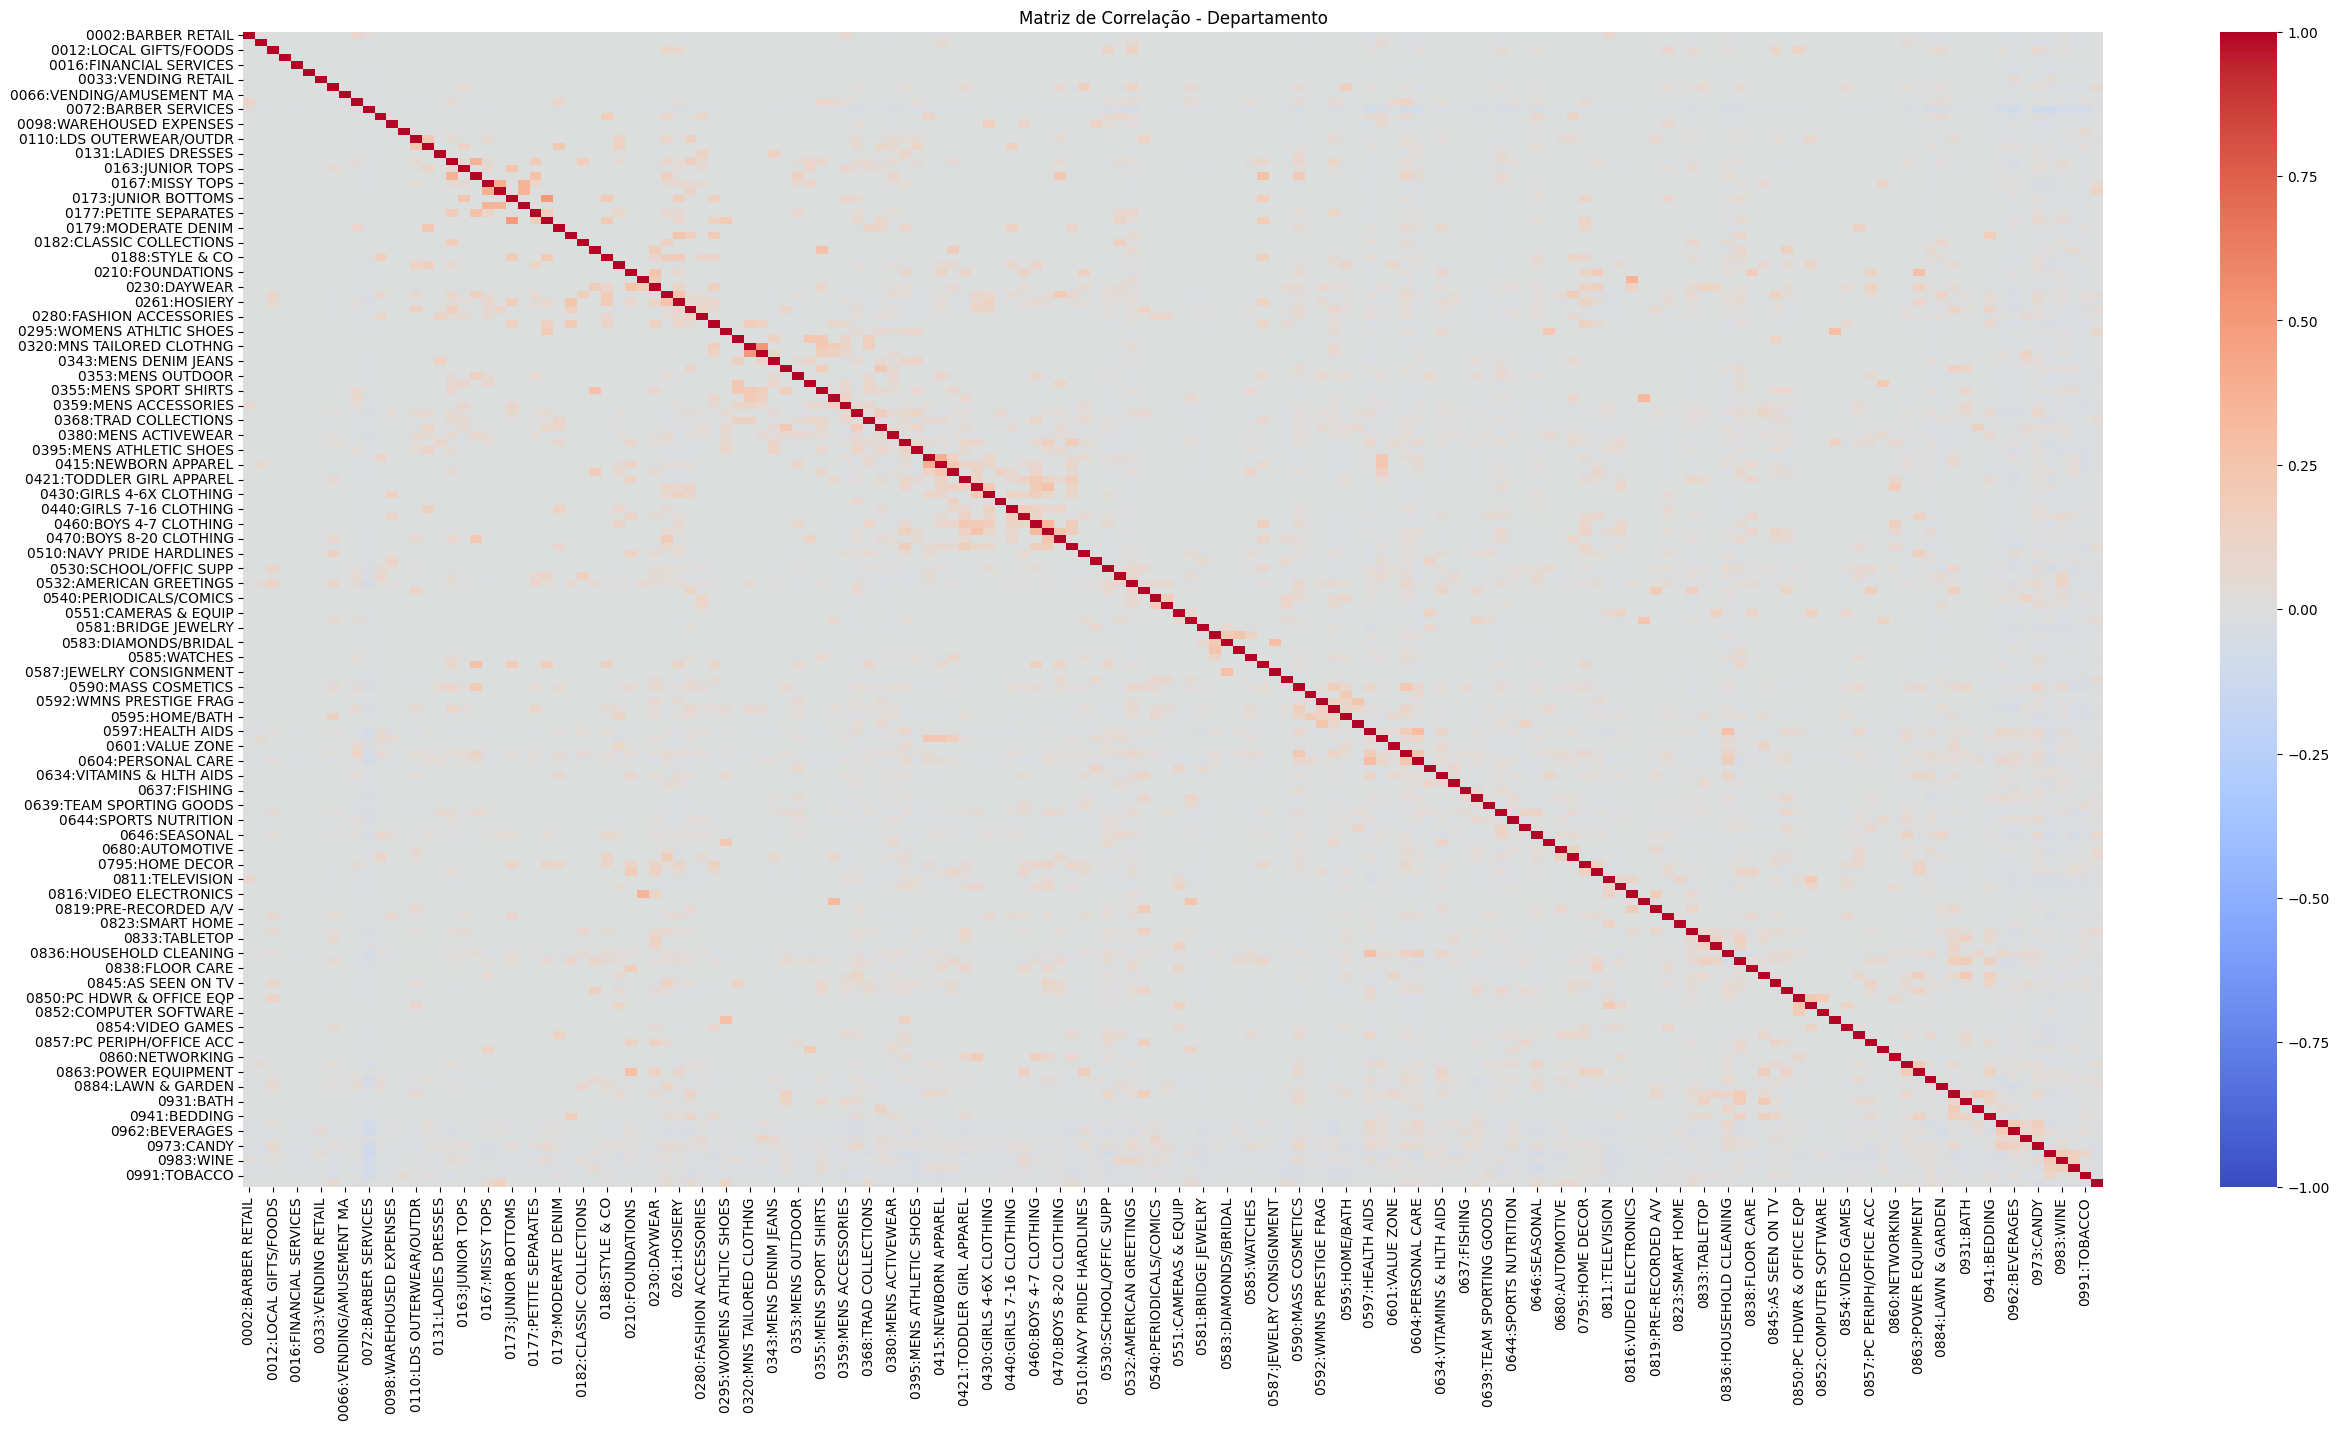

In [346]:
associacao_departamentos = df_pivot.corr()
plt.figure(figsize=(30, 15))
sns.heatmap(associacao_departamentos, cmap='coolwarm', annot=False, vmin=-1, vmax=1)
plt.title('Matriz de Correlação - Departamento')
plt.show()

### Realizar Market Basket Analysis com Apriori

In [351]:
itemsets_frequentes = apriori(df_pivot, min_support=0.02, use_colnames=True, verbose=1)

Processing 165 combinations | Sampling itemset size 3


In [352]:
len(itemsets_frequentes)

36

In [353]:
itemsets_frequentes['tamanho'] = itemsets_frequentes['itemsets'].apply(lambda x: len(x))

In [354]:
itemsets_frequentes

,support,itemsets,tamanho
0,0.057643,frozenset({0072:BARBER SERVICES}),1
1,0.024704,frozenset({0360:MENS FURNISHINGS}),1
2,0.024189,frozenset({0380:MENS ACTIVEWEAR}),1
3,0.027277,frozenset({0530:SCHOOL/OFFIC SUPP}),1
4,0.053011,frozenset({0532:AMERICAN GREETINGS}),1
5,0.026248,frozenset({0590:MASS COSMETICS}),1
6,0.022645,frozenset({0593:PRESTIGE COSMETICS}),1
7,0.102934,frozenset({0597:HEALTH AIDS}),1
8,0.067936,frozenset({0603:BEAUTY CARE}),1
9,0.077200,frozenset({0604:PERSONAL CARE}),1


In [355]:
itemsets_frequentes[itemsets_frequentes.tamanho == 2]

,support,itemsets,tamanho
24,0.021616,"frozenset({0603:BEAUTY CARE, 0597:HEALTH AIDS})",2
25,0.032939,"frozenset({0597:HEALTH AIDS, 0604:PERSONAL CARE})",2
26,0.031395,"frozenset({0597:HEALTH AIDS, 0836:HOUSEHOLD CL...",2
27,0.023160,"frozenset({0973:CANDY, 0597:HEALTH AIDS})",2
28,0.021101,"frozenset({0603:BEAUTY CARE, 0604:PERSONAL CARE})",2
29,0.022131,"frozenset({0962:BEVERAGES, 0961:GENERAL GROCER...",2
30,0.020072,"frozenset({0973:CANDY, 0961:GENERAL GROCERIES})",2
31,0.034483,"frozenset({0973:CANDY, 0962:BEVERAGES})",2
32,0.025219,"frozenset({0982:SPIRITS, 0962:BEVERAGES})",2
33,0.039629,"frozenset({0983:WINE, 0982:SPIRITS})",2


In [358]:
transacoes_spirits = len(df_pivot[df_pivot['0982:SPIRITS'] == True])
total_transacoes = len(df_pivot)
suporte_spirits = transacoes_spirits / total_transacoes

print(f'Suporte transacoes_spirits {suporte_spirits}')

Suporte transacoes_spirits 0.16160576428203807


In [363]:
regras_associacao = association_rules(itemsets_frequentes, metric='lift', min_threshold=3)
regras_associacao.sort_values("lift", ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,frozenset({0604:PERSONAL CARE}),frozenset({0597:HEALTH AIDS}),0.077200,0.102934,0.032939,0.426667,4.145067,1.0,0.024992,1.564651,0.822225,0.223776,0.360880,0.373333
2,frozenset({0597:HEALTH AIDS}),frozenset({0604:PERSONAL CARE}),0.102934,0.077200,0.032939,0.320000,4.145067,1.0,0.024992,1.357059,0.845812,0.223776,0.263112,0.373333
7,frozenset({0604:PERSONAL CARE}),frozenset({0603:BEAUTY CARE}),0.077200,0.067936,0.021101,0.273333,4.023384,1.0,0.015857,1.282657,0.814319,0.170124,0.220368,0.291970
6,frozenset({0603:BEAUTY CARE}),frozenset({0604:PERSONAL CARE}),0.067936,0.077200,0.021101,0.310606,4.023384,1.0,0.015857,1.338567,0.806225,0.170124,0.252932,0.291970
5,frozenset({0836:HOUSEHOLD CLEANING}),frozenset({0597:HEALTH AIDS}),0.081318,0.102934,0.031395,0.386076,3.750728,1.0,0.023024,1.461201,0.798301,0.205387,0.315631,0.345538
4,frozenset({0597:HEALTH AIDS}),frozenset({0836:HOUSEHOLD CLEANING}),0.102934,0.081318,0.031395,0.305000,3.750728,1.0,0.023024,1.321845,0.817537,0.205387,0.243482,0.345538
8,frozenset({0962:BEVERAGES}),frozenset({0961:GENERAL GROCERIES}),0.130211,0.050952,0.022131,0.169960,3.335689,1.0,0.015496,1.143377,0.805036,0.139159,0.125398,0.302152
9,frozenset({0961:GENERAL GROCERIES}),frozenset({0962:BEVERAGES}),0.050952,0.130211,0.022131,0.434343,3.335689,1.0,0.015496,1.537663,0.737805,0.139159,0.349662,0.302152
1,frozenset({0597:HEALTH AIDS}),frozenset({0603:BEAUTY CARE}),0.102934,0.067936,0.021616,0.210000,3.091136,1.0,0.014623,1.179828,0.754119,0.144828,0.152419,0.264091
0,frozenset({0603:BEAUTY CARE}),frozenset({0597:HEALTH AIDS}),0.067936,0.102934,0.021616,0.318182,3.091136,1.0,0.014623,1.315697,0.725803,0.144828,0.239947,0.264091
